Aufgabe 2

Laden der Daten

In [101]:
import os
import pandas as pd 
import matplotlib.pyplot as plt 

ordnerName = 'Datensätze'
dateiNamen = [
    'mpi_roof_2014a.csv',
    'mpi_roof_2014b.csv',
    'mpi_roof_2015a.csv',
    'mpi_roof_2015b.csv',
    'mpi_roof_2016a.csv',
    'mpi_roof_2016b.csv'
]

datensatzArray = []

for datensatzName in dateiNamen:
    pfadName = os.path.join(ordnerName, datensatzName)
    print(f"Lade Datei: {pfadName}")
    datensatzArray.append(pd.read_csv(pfadName, encoding='ISO-8859-1'))
    
datensatz = pd.concat(datensatzArray, ignore_index = True)
print("Datensätze erfolgreich zusammengefügt")
display(datensatz)

Lade Datei: Datensätze/mpi_roof_2014a.csv
Lade Datei: Datensätze/mpi_roof_2014b.csv
Lade Datei: Datensätze/mpi_roof_2015a.csv
Lade Datei: Datensätze/mpi_roof_2015b.csv
Lade Datei: Datensätze/mpi_roof_2016a.csv
Lade Datei: Datensätze/mpi_roof_2016b.csv
Datensätze erfolgreich zusammengefügt


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC),CO2 (ppm)
0,01.01.2014 00:10:00,987.54,-0.11,274.03,-4.33,73.10,6.06,4.43,1.63,2.79,...,2.25,3.91,204.6,0.0,0.0,0.0,0.0,0.0,10.36,413.5
1,01.01.2014 00:20:00,987.39,-0.07,274.08,-4.38,72.60,6.08,4.41,1.66,2.78,...,2.31,3.16,199.4,0.0,0.0,0.0,0.0,0.0,10.32,413.6
2,01.01.2014 00:30:00,987.18,-0.07,274.10,-4.34,72.80,6.08,4.42,1.65,2.79,...,2.58,3.67,190.5,0.0,0.0,0.0,0.0,0.0,10.31,414.1
3,01.01.2014 00:40:00,987.18,0.20,274.37,-4.29,71.70,6.20,4.44,1.75,2.80,...,2.59,4.13,178.9,0.0,0.0,0.0,0.0,0.0,10.31,413.3
4,01.01.2014 00:50:00,986.97,0.43,274.62,-4.29,70.50,6.30,4.44,1.86,2.80,...,3.65,5.69,173.7,0.0,0.0,0.0,0.0,0.0,10.33,412.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157461,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,...,0.67,1.52,240.0,0.0,0.0,0.0,0.0,0.0,7.37,429.8
157462,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,...,1.14,1.92,234.3,0.0,0.0,0.0,0.0,0.0,7.29,428.7
157463,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,...,1.08,2.00,215.2,0.0,0.0,0.0,0.0,0.0,7.21,428.6
157464,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,...,1.49,2.16,225.8,0.0,0.0,0.0,0.0,0.0,7.14,430.0


Reduktion der Messfrequenz

In [102]:
datensatz['Date Time'] = pd.to_datetime(datensatz['Date Time'], format='%d.%m.%Y %H:%M:%S')

datensatz.set_index('Date Time', inplace = True)

datensatzStündlich = datensatz.resample('h').mean()

display(datensatzStündlich)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),...,wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC),CO2 (ppm)
Date Time,,,,,,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,987.252000,0.076000,274.240000,-4.326000,72.140000,6.144000,4.428000,1.710000,2.792000,4.486000,...,2.676000,4.112000,189.420000,0.0,0.0,0.0,0.0,0.0,10.326000,413.440000
2014-01-01 01:00:00,986.775000,0.968333,275.173333,-4.453333,66.945000,6.553333,4.386667,2.168333,2.771667,4.445000,...,3.046667,4.695000,186.400000,0.0,0.0,0.0,0.0,0.0,10.598333,411.500000
2014-01-01 02:00:00,986.448333,1.430000,275.661667,-4.453333,64.758333,6.778333,4.388333,2.390000,2.770000,4.448333,...,2.630000,3.643333,190.350000,0.0,0.0,0.0,0.0,0.0,11.318333,411.083333
2014-01-01 03:00:00,986.171667,2.125000,276.380000,-4.361667,62.033333,7.120000,4.416667,2.703333,2.788333,4.478333,...,1.825000,3.118333,196.150000,0.0,0.0,0.0,0.0,0.0,11.996667,410.683333
2014-01-01 04:00:00,986.251667,2.771667,277.025000,-4.586667,58.221667,7.460000,4.341667,3.118333,2.741667,4.401667,...,0.908333,1.550000,227.016667,0.0,0.0,0.0,0.0,0.0,12.791667,410.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 20:00:00,1001.410000,-2.503333,270.546667,-7.025000,71.080000,5.086667,3.601667,1.485000,2.240000,3.596667,...,0.923333,1.526667,203.533333,0.0,0.0,0.0,0.0,0.0,9.585000,431.000000
2016-12-31 21:00:00,1001.063333,-2.653333,270.426667,-6.970000,72.016667,5.025000,3.616667,1.406667,2.248333,3.611667,...,0.573333,1.250000,98.366667,0.0,0.0,0.0,0.0,0.0,8.631667,430.250000
2016-12-31 22:00:00,1000.511667,-3.553333,269.568333,-7.348333,74.916667,4.698333,3.515000,1.188333,2.188333,3.513333,...,0.816667,1.410000,167.958333,0.0,0.0,0.0,0.0,0.0,7.885000,434.000000


Feature Engineering

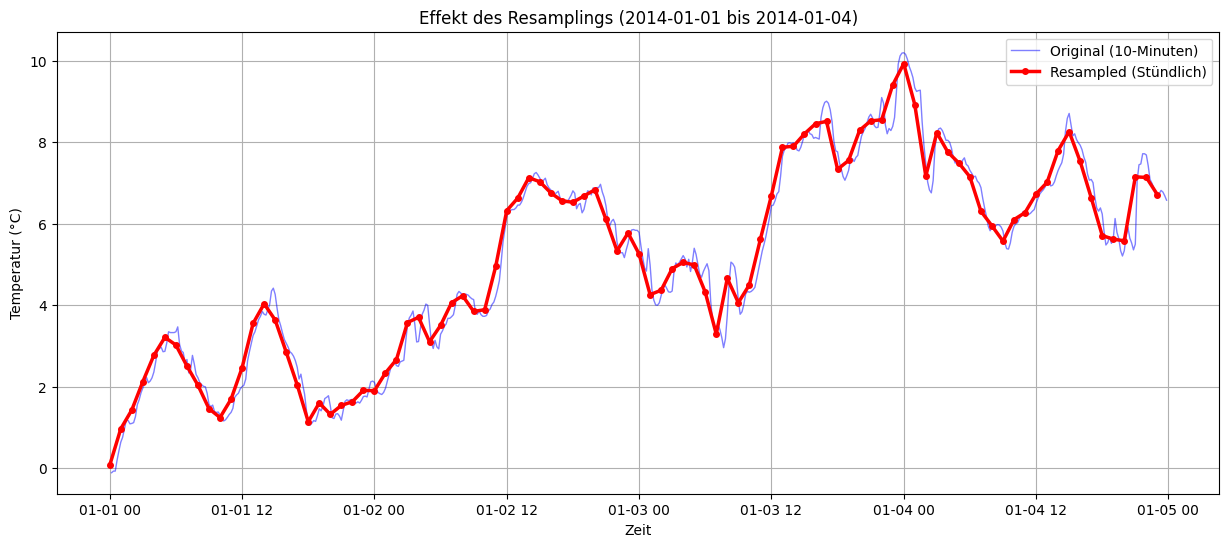

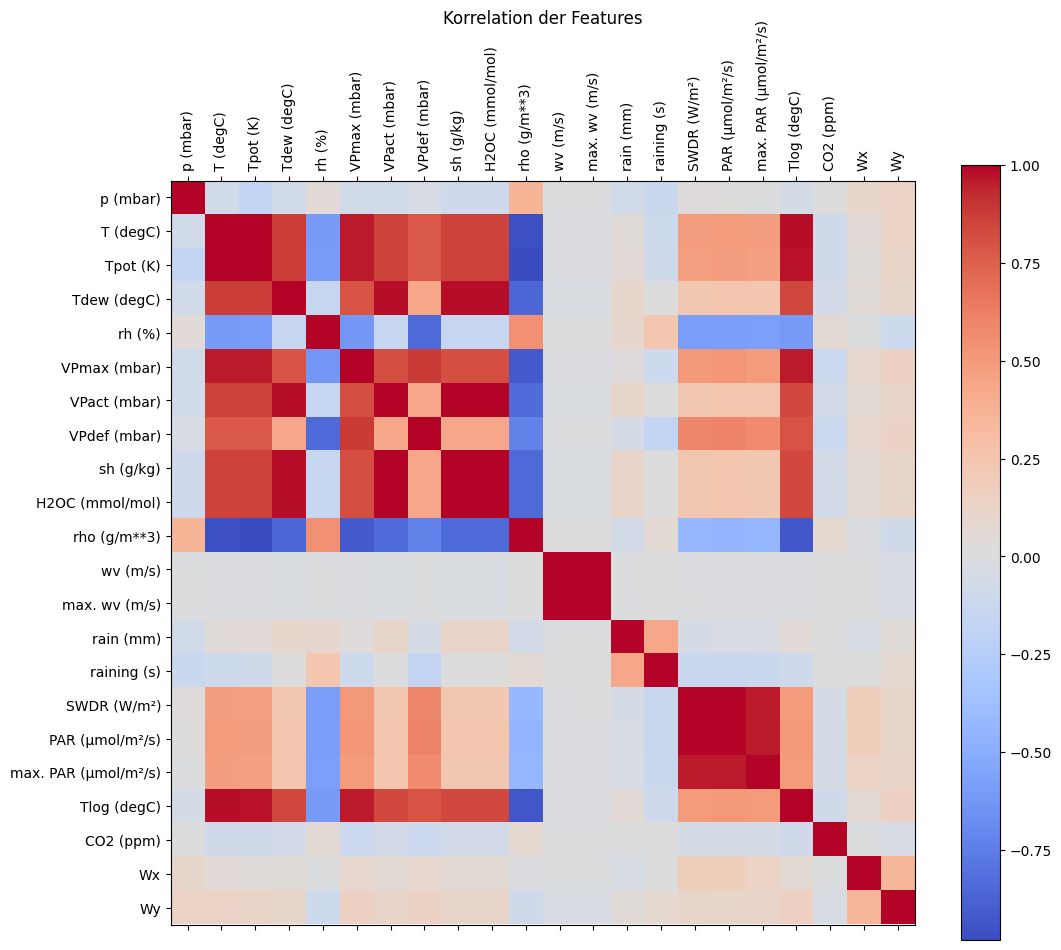

In [103]:
import numpy as np

# Flüssigen Übergang in Windrichtung machen

windrichtung_rad = datensatz['wd (deg)'] * np.pi / 180

datensatz['Wx'] = np.sin(windrichtung_rad)
datensatz['Wy'] = np.cos(windrichtung_rad)

datensatz = datensatz.drop(columns=['wd (deg)'])


datensatz.sort_index(inplace=True) 

datensatzStündlich = datensatz.resample('h').mean(numeric_only=True)

# PLOT: Resampling Vergleich

start_datum = '2014-01-01'
end_datum = '2014-01-04'

original_3tage = datensatz.loc[start_datum:end_datum]
stündlich_3tage = datensatzStündlich.loc[start_datum:end_datum]

plt.figure(figsize=(15, 6))

plt.plot(original_3tage.index, original_3tage['T (degC)'], 
         label='Original (10-Minuten)', color='blue', alpha=0.5, linewidth=1)

plt.plot(stündlich_3tage.index, stündlich_3tage['T (degC)'], 
         label='Resampled (Stündlich)', color='red', linewidth=2.5, marker='o', markersize=4)

plt.title(f'Effekt des Resamplings ({start_datum} bis {end_datum})')
plt.ylabel('Temperatur (°C)')
plt.xlabel('Zeit')
plt.legend()
plt.grid(True)
plt.show()

# PLOT: Korrelation (Heatmap)
korrelation = datensatzStündlich.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.matshow(korrelation, fignum=1, cmap='coolwarm')
plt.colorbar()

cols = korrelation.columns
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)
plt.title("Korrelation der Features", y=1.2)
plt.show()

spalten_zum_loeschen = [
    'Tpot (K)',          # Ist fast identisch mit T (degC)
    'rho (g/m**3)',      # Ist direkt abhängig von Druck (p) und Temperatur
    'H2OC (mmol/mol)',   # Ist redundant zu sh (g/kg)
    'Tdew (degC)',       # Kann man oft auch weglassen, da es in T und Feuchte steckt
    'VPmax (mbar)',      # Redundant
    'VPdef (mbar)'       # Redundant
]

datensatzStündlich = datensatzStündlich.drop(columns=spalten_zum_loeschen)



Daten visualisieren

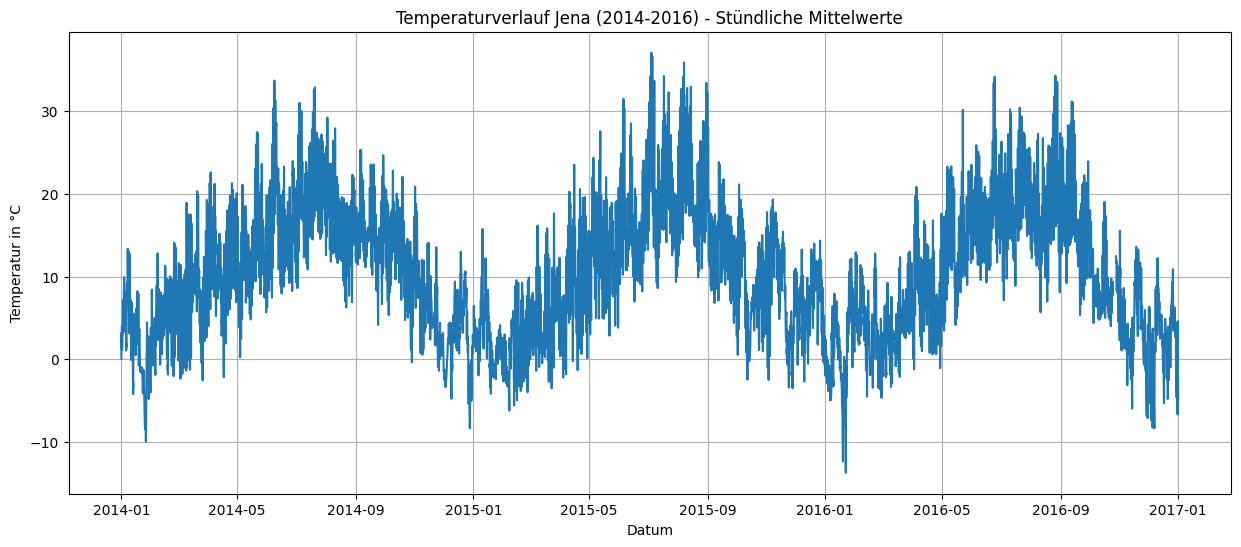

In [104]:
plt.figure(figsize = (15, 6))

plt.plot(datensatzStündlich.index, datensatzStündlich['T (degC)'])

plt.title("Temperaturverlauf Jena (2014-2016) - Stündliche Mittelwerte")
plt.xlabel("Datum")
plt.ylabel("Temperatur in °C")
plt.grid(True)

plt.show()

Aufteilung der Daten (70% Training, 20% Validierung, 10% Test)

In [105]:
n = len(datensatzStündlich)

trainingsEndeIndex = int(n * 0.7)
validierungsEndeIndex = int(n * 0.9)

trainingsDatensatz = datensatzStündlich.iloc[:trainingsEndeIndex]
validierungsDatensatz = datensatzStündlich.iloc[trainingsEndeIndex:validierungsEndeIndex]
testDatensatz = datensatzStündlich.iloc[validierungsEndeIndex:]

display(trainingsDatensatz)
display(validierungsDatensatz)
display(testDatensatz)

,p (mbar),T (degC),rh (%),VPact (mbar),sh (g/kg),wv (m/s),max. wv (m/s),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC),CO2 (ppm),Wx,Wy
Date Time,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,987.252000,0.076000,72.140000,4.428000,2.792000,2.676000,4.112000,0.0,0.0,0.0,0.0,0.0,10.326000,413.440000,-0.160349,-0.965898
2014-01-01 01:00:00,986.775000,0.968333,66.945000,4.386667,2.771667,3.046667,4.695000,0.0,0.0,0.0,0.0,0.0,10.598333,411.500000,-0.103355,-0.957993
2014-01-01 02:00:00,986.448333,1.430000,64.758333,4.388333,2.770000,2.630000,3.643333,0.0,0.0,0.0,0.0,0.0,11.318333,411.083333,-0.178113,-0.975999
2014-01-01 03:00:00,986.171667,2.125000,62.033333,4.416667,2.788333,1.825000,3.118333,0.0,0.0,0.0,0.0,0.0,11.996667,410.683333,-0.266818,-0.921515
2014-01-01 04:00:00,986.251667,2.771667,58.221667,4.341667,2.741667,0.908333,1.550000,0.0,0.0,0.0,0.0,0.0,12.791667,410.133333,-0.648879,-0.630234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-02-07 00:00:00,981.875000,4.500000,83.133333,7.005000,4.451667,1.281667,2.320000,0.0,0.0,0.0,0.0,0.0,14.720000,420.033333,-0.190175,-0.793145
2016-02-07 01:00:00,981.165000,4.373333,82.783333,6.913333,4.395000,1.648333,2.731667,0.0,0.0,0.0,0.0,0.0,14.421667,419.200000,-0.012161,-0.983949
2016-02-07 02:00:00,980.570000,2.890000,87.333333,6.566667,4.176667,2.090000,3.488333,0.0,0.0,0.0,0.0,0.0,14.140000,425.333333,0.098786,-0.983081


,p (mbar),T (degC),rh (%),VPact (mbar),sh (g/kg),wv (m/s),max. wv (m/s),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC),CO2 (ppm),Wx,Wy
Date Time,,,,,,,,,,,,,,,,
2016-02-07 05:00:00,979.210000,4.856667,75.083333,6.488333,4.131667,1.568333,3.120000,0.0,0.0,0.000000,0.000000,0.000000,13.775000,418.883333,0.543869,-0.809931
2016-02-07 06:00:00,978.798333,5.101667,73.683333,6.478333,4.126667,1.311667,2.573333,0.0,0.0,0.000000,0.000000,0.000000,14.251667,417.616667,0.209309,-0.932219
2016-02-07 07:00:00,978.805000,5.030000,73.233333,6.403333,4.080000,1.743333,2.933333,0.0,0.0,0.638333,1.961667,3.088333,14.545000,418.250000,-0.046644,-0.985447
2016-02-07 08:00:00,978.691667,4.686667,73.800000,6.301667,4.013333,1.601667,2.643333,0.0,0.0,31.456667,63.191667,72.328333,14.706667,420.500000,0.028342,-0.957316
2016-02-07 09:00:00,978.505000,4.185000,76.716667,6.323333,4.028333,1.758333,3.283333,0.0,0.0,75.318333,149.680000,154.343333,14.978333,424.933333,0.326774,-0.940636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-13 05:00:00,990.988333,15.136667,87.766667,15.120000,9.543333,0.755000,1.350000,0.0,0.0,0.268333,1.963333,3.185000,28.510000,480.316667,0.800826,-0.553031
2016-09-13 06:00:00,991.308333,15.158333,87.650000,15.118333,9.541667,0.855000,1.463333,0.0,0.0,41.480000,79.663333,93.756667,27.823333,487.700000,0.737636,-0.266581
2016-09-13 07:00:00,991.468333,17.538333,77.783333,15.611667,9.853333,0.535000,1.223333,0.0,0.0,171.526667,322.811667,346.493333,28.051667,486.750000,0.310043,-0.587271


,p (mbar),T (degC),rh (%),VPact (mbar),sh (g/kg),wv (m/s),max. wv (m/s),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC),CO2 (ppm),Wx,Wy
Date Time,,,,,,,,,,,,,,,,
2016-09-13 10:00:00,991.031667,25.826667,52.163333,17.345000,10.958333,0.855000,1.806667,0.0,0.0,557.981667,1088.190000,1101.610000,37.976667,436.033333,0.795756,-0.331630
2016-09-13 11:00:00,990.551667,28.365000,45.603333,17.616667,11.138333,1.191667,2.513333,0.0,0.0,619.550000,1214.060000,1221.491667,41.013333,417.433333,0.671388,-0.633702
2016-09-13 12:00:00,990.003333,29.523333,41.321667,17.078333,10.801667,1.561667,3.240000,0.0,0.0,642.490000,1259.588333,1275.771667,43.183333,405.250000,0.899471,0.388441
2016-09-13 13:00:00,989.405000,30.636667,36.335000,16.010000,10.125000,2.150000,4.566667,0.0,0.0,615.626667,1207.528333,1234.330000,44.713333,398.466667,0.953743,0.099066
2016-09-13 14:00:00,988.973333,31.021667,34.550000,15.561667,9.846667,2.001667,4.103333,0.0,0.0,530.750000,1034.651667,1060.745000,45.886667,397.916667,0.658780,-0.678523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 20:00:00,1001.410000,-2.503333,71.080000,3.601667,2.240000,0.923333,1.526667,0.0,0.0,0.000000,0.000000,0.000000,9.585000,431.000000,-0.375740,-0.870148
2016-12-31 21:00:00,1001.063333,-2.653333,72.016667,3.616667,2.248333,0.573333,1.250000,0.0,0.0,0.000000,0.000000,0.000000,8.631667,430.250000,0.361361,-0.004492
2016-12-31 22:00:00,1000.511667,-3.553333,74.916667,3.515000,2.188333,0.816667,1.410000,0.0,0.0,0.000000,0.000000,0.000000,7.885000,434.000000,-0.254501,-0.602736


Alle Datensets plotten

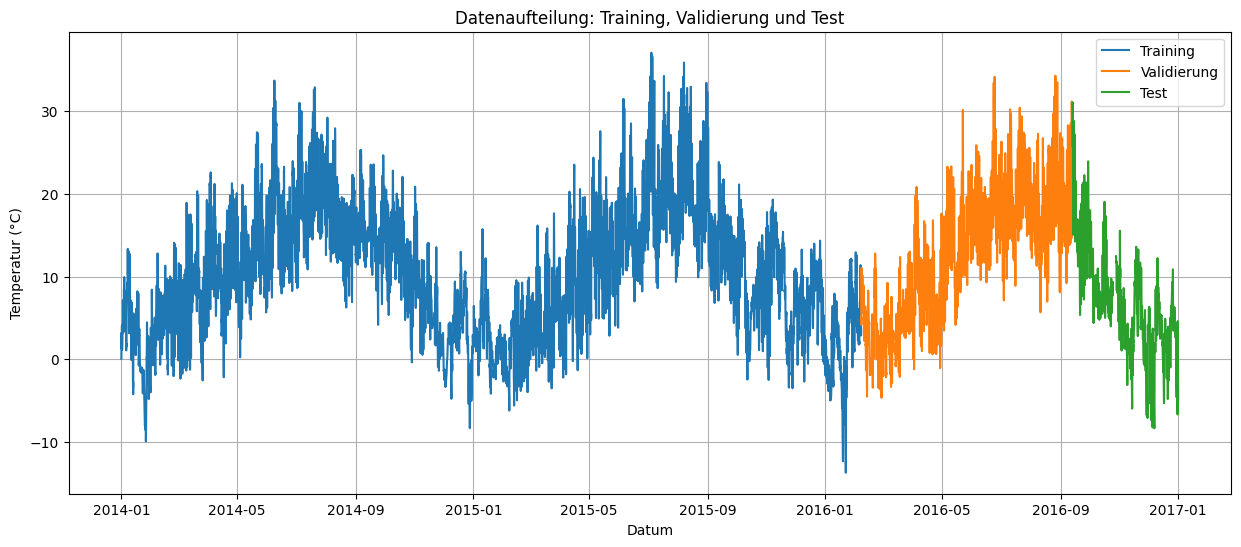

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(trainingsDatensatz.index, trainingsDatensatz['T (degC)'], label='Training')
plt.plot(validierungsDatensatz.index, validierungsDatensatz['T (degC)'], label='Validierung')
plt.plot(testDatensatz.index, testDatensatz['T (degC)'], label='Test')

plt.title("Datenaufteilung: Training, Validierung und Test")
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.legend() 
plt.grid(True)
plt.show()

Normalisieren

In [107]:
trainingsDatensatzDurchschnitt = trainingsDatensatz.mean()
trainingsDatensatzStandardabweichung = trainingsDatensatz.std()

trainingsDatensatz = (trainingsDatensatz - trainingsDatensatzDurchschnitt) / trainingsDatensatzStandardabweichung
validierungsDatensatz = (validierungsDatensatz - trainingsDatensatzDurchschnitt) / trainingsDatensatzStandardabweichung
testDatensatz = (testDatensatz - trainingsDatensatzDurchschnitt) / trainingsDatensatzStandardabweichung

trainingsDatensatz = trainingsDatensatz.fillna(0)
validierungsDatensatz = validierungsDatensatz.fillna(0)
testDatensatz = testDatensatz.fillna(0)

print("Neuer Durchschnitt (Training):")
print(trainingsDatensatz['T (degC)'].mean())

display(trainingsDatensatz)

Neuer Durchschnitt (Training):
-4.939416182984458e-17


,p (mbar),T (degC),rh (%),VPact (mbar),sh (g/kg),wv (m/s),max. wv (m/s),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC),CO2 (ppm),Wx,Wy
Date Time,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,-0.298860,-1.319497,-0.241237,-1.327299,-1.320166,0.018078,0.018544,-0.120185,-0.278845,-0.606696,-0.609807,-0.599247,-1.398553,0.044275,0.002898,-1.023050
2014-01-01 01:00:00,-0.357913,-1.203010,-0.558267,-1.337376,-1.327965,0.021125,0.023026,-0.120185,-0.278845,-0.606696,-0.609807,-0.599247,-1.363726,0.039932,0.109341,-1.010910
2014-01-01 02:00:00,-0.398355,-1.142743,-0.691710,-1.336970,-1.328604,0.017700,0.014941,-0.120185,-0.278845,-0.606696,-0.609807,-0.599247,-1.271648,0.038999,-0.030279,-1.038561
2014-01-01 03:00:00,-0.432606,-1.052016,-0.858006,-1.330062,-1.321572,0.011082,0.010905,-0.120185,-0.278845,-0.606696,-0.609807,-0.599247,-1.184900,0.038104,-0.195946,-0.954890
2014-01-01 04:00:00,-0.422702,-0.967599,-1.090617,-1.348348,-1.339472,0.003547,-0.001151,-0.120185,-0.278845,-0.606696,-0.609807,-0.599247,-1.083231,0.036872,-0.909492,-0.507569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-02-07 00:00:00,-0.964538,-0.741978,0.429643,-0.698995,-0.683585,0.006616,0.004768,-0.120185,-0.278845,-0.606696,-0.609807,-0.599247,-0.836626,0.059035,-0.052806,-0.757752
2016-02-07 01:00:00,-1.052436,-0.758514,0.408283,-0.721345,-0.705320,0.009630,0.007933,-0.120185,-0.278845,-0.606696,-0.609807,-0.599247,-0.874778,0.057170,0.279657,-1.050771
2016-02-07 02:00:00,-1.126098,-0.952151,0.685952,-0.805866,-0.789064,0.013261,0.013750,-0.120185,-0.278845,-0.606696,-0.609807,-0.599247,-0.910799,0.070900,0.486865,-1.049438


Windowing

In [108]:
import numpy as np 
from tensorflow.keras.utils import timeseries_dataset_from_array

FENSTER_GROESSE = 24
VORHERSAGE_GROESSE = 1
BATCH_GROESSE = 32

zielSpaltenIndex = list(trainingsDatensatz.columns).index('T (degC)')

def erstelleDatensatz(daten, zielIndex, fenster, batchSize, zufaelligkeit):
    eingabewerte = daten.to_numpy()[:-fenster]
    zielwerte = daten.iloc[fenster:, zielIndex].to_numpy()
    
    datensatz = timeseries_dataset_from_array(
        data = eingabewerte,
        targets = zielwerte,
        sequence_length = fenster,
        batch_size = batchSize,
        shuffle = zufaelligkeit,
    )
    return datensatz

trainingsDatensatzFenster = erstelleDatensatz(trainingsDatensatz, zielSpaltenIndex, FENSTER_GROESSE, BATCH_GROESSE, True)
validierungsDatensatzFenster = erstelleDatensatz(validierungsDatensatz, zielSpaltenIndex, FENSTER_GROESSE, BATCH_GROESSE, False)
testDatensatzFenster = erstelleDatensatz(testDatensatz, zielSpaltenIndex, FENSTER_GROESSE, BATCH_GROESSE, False)



### Aufgabe 3 - Modellaufbau und Training

In [109]:
import tensorflow as tf 
from tensorflow.keras import layers

modell = tf.keras.Sequential()

anzahlSpalten = trainingsDatensatz.shape[1]

# Schicht 1
modell.add(layers.LSTM(units = 32, input_shape = (FENSTER_GROESSE, anzahlSpalten)))

# Schicht 2
modell.add(layers.Dropout(0.2))

# Schicht 3
modell.add(layers.Dense(units = 1))

# Hyperparameter festlegen
modell.compile(
    loss = 'mae',     
    optimizer = 'adam',
    metrics = ['mae'],
)

modell.summary()

print("Training starten ...")

verlauf = modell.fit(
    trainingsDatensatzFenster,
    epochs = 10,
    validation_data = validierungsDatensatzFenster,
)



/Users/lucamartens/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,305 (24.63 KB)

 Trainable params: 6,305 (24.63 KB)

 Non-trainable params: 0 (0.00 B)

Training starten ...
Epoch 1/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2807 - mae: 0.2807 - val_loss: 0.0888 - val_mae: 0.0888
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1225 - mae: 0.1225 - val_loss: 0.0791 - val_mae: 0.0791
Epoch 3/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1061 - mae: 0.1061 - val_loss: 0.0701 - val_mae: 0.0701
Epoch 4/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0985 - mae: 0.0985 - val_loss: 0.0631 - val_mae: 0.0631
Epoch 5/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0954 - mae: 0.0954 - val_loss: 0.0605 - val_mae: 0.0605
Epoch 6/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0928 - mae: 0.0928 - val_loss: 0.0588 - val_mae: 0.0588
Epoch 7/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0905 - mae: 0.0905 - val_loss: 0.0566 - val_mae: 0.0566
Epoch 8/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0885 - mae: 0.0885 - val_loss: 0.0647 - val_mae: 0.0647
Epoch 9/10
574/574 ━━━━━━━━━━━━━━━━

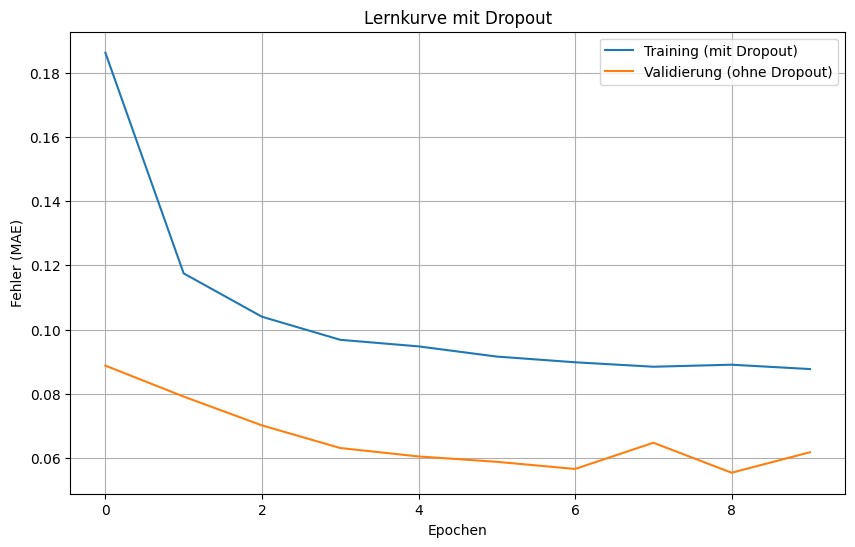

In [110]:
loss = verlauf.history['loss']
val_loss = verlauf.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(loss, label='Training (mit Dropout)')
plt.plot(val_loss, label='Validierung (ohne Dropout)')
plt.title('Lernkurve mit Dropout')
plt.xlabel('Epochen')
plt.ylabel('Fehler (MAE)')
plt.legend()
plt.grid(True)
plt.show()

### Aufgabe 4 - Evaluierung des Modells

In [111]:
testergebnis = modell.evaluate(testDatensatzFenster)

scaled_mae = testergebnis[1] 

standardabweichung_temp = trainingsDatensatzStandardabweichung['T (degC)']

echter_fehler = scaled_mae * standardabweichung_temp

print(f"--- Ergebnis ---")
print(f"Normalisierter Fehler (Modell): {scaled_mae:.4f}")
print(f"Standardabweichung (Skalierungsfaktor): {standardabweichung_temp:.2f}")
print(f"-------------------------------------------")
print(f"Echter Fehler: +/- {echter_fehler:.2f} °C")

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0491 - mae: 0.0491
--- Ergebnis ---
Normalisierter Fehler (Modell): 0.0503
Standardabweichung (Skalierungsfaktor): 7.66
-------------------------------------------
Echter Fehler: +/- 0.39 °C


visualisieren

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


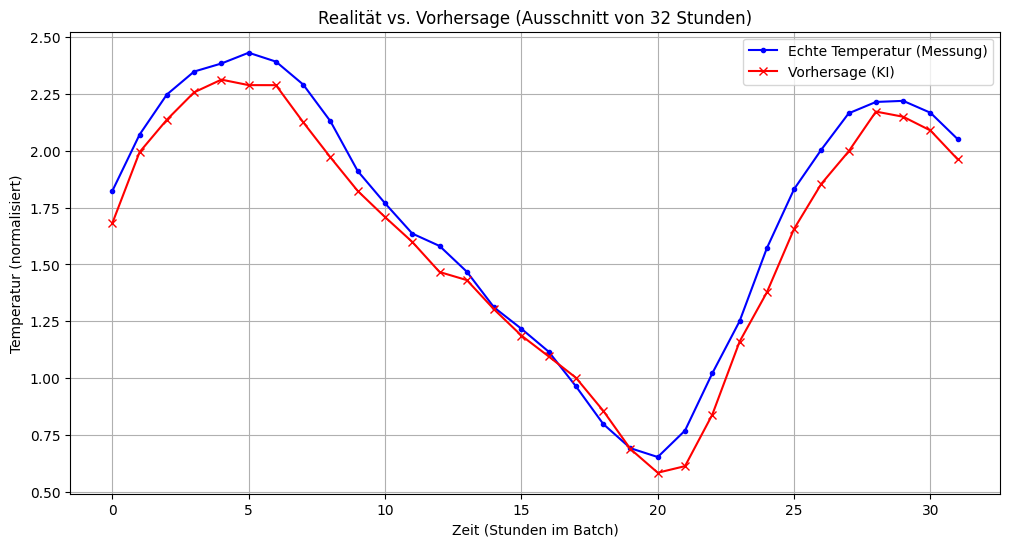

In [112]:
input_batch, echte_temperatur = next(iter(testDatensatzFenster))

vorhersage = modell.predict(input_batch)

plt.figure(figsize=(12, 6))

plt.plot(echte_temperatur, label = 'Echte Temperatur (Messung)', color = 'blue', marker = '.')

plt.plot(vorhersage, label = 'Vorhersage (KI)', color = 'red', marker = 'x')

plt.title('Realität vs. Vorhersage (Ausschnitt von 32 Stunden)')
plt.ylabel('Temperatur (normalisiert)')
plt.xlabel('Zeit (Stunden im Batch)')
plt.legend()
plt.grid(True)

plt.show()

### Aufgabe 5 - Hyperparameter-Tuning und Darstellung der Ergebnisse

##### Aufgabe 5.1 - Hyperparamter-Tuning <br>
<br>
Zur Analyse des Modellverhaltens wurden gezielt drei Hyperparameter variiert, während alle anderen konstant gehalten wurden.<br>
<br>
Zur Bewertung der Hyperparameter-Variationen wurde der MAE (Mean absolute error) auf dem Testdatensatz herangezogen, da dieser direkt die Vorhersagegenauigkeit in der Zielgröße beschreibt. <br>


Dabei gab es folgende Basis:<br>

layer.LSTM(units=32)<br>
FENSTER_GROESSE = 24<br>
layers.Dropout(0.2) <br>
<br>
Test MAE = 0.04557729884982109 -> 4,6% <br>
___

Variante 1: <br>
<br>
layers.LSTM(units=32) -> units=64<br>
<br>
Test MAE = 0.04206804186105728 -> 4,2% <br>
___

Variante 2: <br>
<br>
FENSTER_GROESSE = 24 -> 48<br>
<br>
Test MAE = 0.04994109272956848 -> 5% <br>
___

Variante 3: <br>
<br>
layers.Dropout(0.2) -> 0.4<br>
<br>
Test MAE = 0.0459764190018177 -> 4,6%<br>
___
<br>
Zur Hyperparameteranalyse wurden die Anzahl der LSTM-Units, die Fenstergröße sowie der Dropout-Wert variiert.<br>
Die Erhöhung der LSTM-Units von 32 auf 64 führte zu einer Reduktion des Test-MAE von 4,6 % auf 4,2 % und stellte damit die beste Anpassung dar.<br>
Die Vergrößerung der Fenstergröße auf 48 verschlechterte den MAE, was darauf hindeutet, dass ein längerer zeitlicher Kontext für diese Aufgabe nicht vorteilhaft ist.<br>
Eine Erhöhung des Dropouts hatte keinen Einfluss auf die Modellgüte.

### Aufgabe 6 - Visualisierung der Ergebnisse


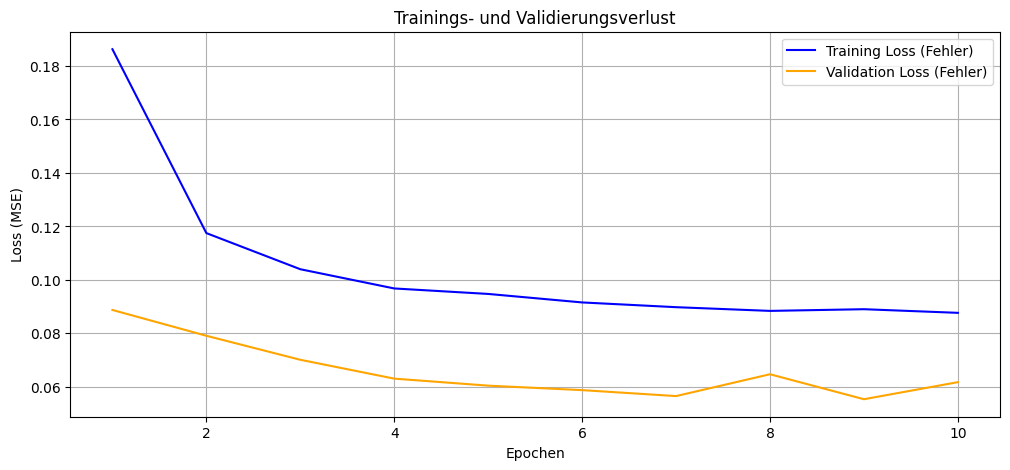

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


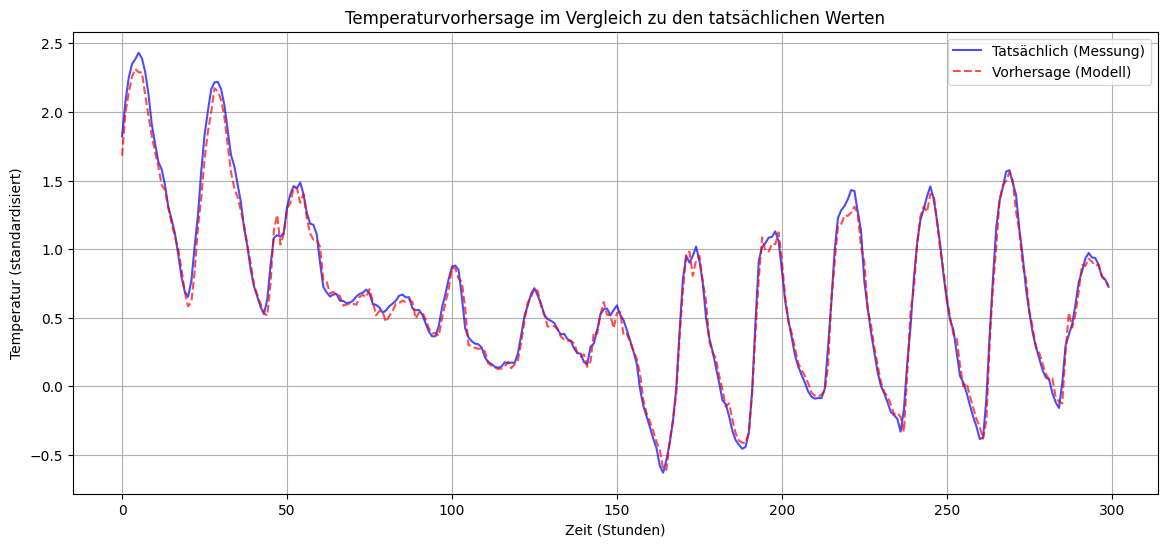

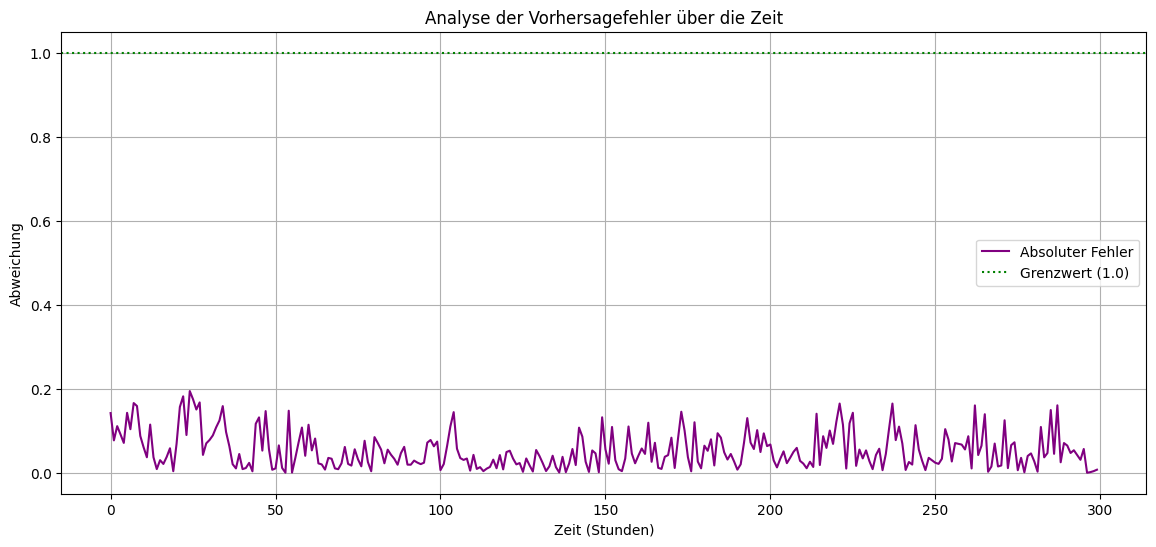

Anzahl der Stunden mit hohem Fehler (> 1.0): 0


In [113]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Darstellung der Trainings- und Validierungsverluste ---
# Das deckt den ersten Punkt ab: "über die Trainingsperioden"
loss = verlauf.history['loss']
val_loss = verlauf.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs, loss, 'b', label='Training Loss (Fehler)')
plt.plot(epochs, val_loss, 'orange', label='Validation Loss (Fehler)')
plt.title('Trainings- und Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# --- Vorbereitung für Punkt 2 & 3 ---
# Wir holen uns echte Daten und Vorhersagen aus dem Test-Set
# (Wir nehmen hier beispielhaft 300 Werte, damit der Plot lesbar bleibt)
inputs, targets = next(iter(testDatensatzFenster.take(10).unbatch().batch(300)))

echte_werte = targets.numpy().flatten()
vorhersagen = modell.predict(inputs).flatten()

# --- 2. Visualisierung: Vorhersagen vs. Tatsächliche Werte ---
plt.figure(figsize=(14, 6))
plt.plot(echte_werte, label='Tatsächlich (Messung)', color='blue', alpha=0.7)
plt.plot(vorhersagen, label='Vorhersage (Modell)', color='red', alpha=0.7, linestyle='--')
plt.title('Temperaturvorhersage im Vergleich zu den tatsächlichen Werten')
plt.xlabel('Zeit (Stunden)')
plt.ylabel('Temperatur (standardisiert)')
plt.legend()
plt.grid(True)
plt.show()

# --- 3. Analyse von Perioden mit hohen Fehlern ---
# Berechnung der absoluten Differenz (Fehler)
fehler = np.abs(echte_werte - vorhersagen)
schwellenwert = 1.0  # Fehlergrenze definieren (anpassbar)

plt.figure(figsize=(14, 6))
plt.plot(fehler, label='Absoluter Fehler', color='purple')
plt.axhline(y=schwellenwert, color='green', linestyle=':', label=f'Grenzwert ({schwellenwert})')
plt.title('Analyse der Vorhersagefehler über die Zeit')
plt.xlabel('Zeit (Stunden)')
plt.ylabel('Abweichung')
plt.legend()
plt.grid(True)
plt.show()

# Text-Ausgabe für die Analyse
hohe_fehler_idx = np.where(fehler > schwellenwert)[0]
print(f"Anzahl der Stunden mit hohem Fehler (> {schwellenwert}): {len(hohe_fehler_idx)}")
if len(hohe_fehler_idx) > 0:
    idx = hohe_fehler_idx[0]
    print(f"Beispiel - Stunde {idx}: Real {echte_werte[idx]:.2f} vs Pred {vorhersagen[idx]:.2f}")